In [ ]:
import pandas as pd
import numpy as np
import json
import os
import zipfile
import glob
import time
import xml.etree.ElementTree as ET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
root_path = '/content/drive/MyDrive/Research stuff/Final Year Design Project/Datasets/Reddit_data/'

negative_path = root_path + 'negative_examples_anonymous/'
positive_path = root_path + 'positive_examples_anonymous/'

In [ ]:
#testing the data

test_data_path = positive_path + 'test_subject625.xml'

tree = ET.parse(test_data_path)
root = tree.getroot()

In [ ]:
count = 0
for post in root.findall('./WRITING'):
    text = post.find('TEXT').text
    timestamp = post.find('DATE').text
    print(timestamp)
    break
    count += 1
#print(count)
ind = timestamp.find('2')
year = timestamp[ind : ind+4]
print(year)

 2015-06-30 21:01:11 
2015


In [ ]:
final_negative_data = []
post_count = 0
neg_time_series = []
neg_posts_per_day = 0
neg_avg_post_dist = []


for name in glob.glob(negative_path + '*.xml'): 
    tree = ET.parse(name)
    root = tree.getroot()

    data = {'text': '', '00-05': 0, '06-11': 0, '12-17': 0, "18-23": 0, 'total_posts': 0, 'avg_posts': 0, 'class': 0}
    time = [0]*24
    years = []

    for post in root.findall('./WRITING'):
        text = post.find('TEXT').text
        timestamp = post.find('DATE').text
        #print(timestamp, text)
        post_count += 1
        data['total_posts'] += 1
        data['text'] += (text + ' ')

        ind = timestamp.find(':')
        hour = timestamp [ind-2 : ind]
        hour = int(hour)

        time[hour] += 1

        if 0 <= hour <= 5:
            data['00-05'] += 1
        
        elif hour <= 11:
            data['06-11'] += 1

        elif hour <= 17:
            data['12-17'] += 1
        
        else:
            data['18-23'] += 1

        ind = timestamp.find('2')
        year = timestamp[ind : ind + 4]
        if year not in years:
            years.append(year)

    final_negative_data.append(data) 
    neg_time_series.append(time)
    
    year_diff = len(years)
    data['avg_posts'] = data['total_posts'] / (year_diff * 365)
    neg_avg_post_dist.append(data['avg_posts'])
    neg_posts_per_day += data['avg_posts']

print(post_count) 

481873


In [ ]:
avg_neg_posts = neg_posts_per_day / (len(final_negative_data))
avg_neg_posts

0.8171478913498333

In [ ]:
from scipy.stats import shapiro
stat, p = shapiro(neg_avg_post_dist)
print(stat, p)
if p > 0.05:
	print('Probably Gaussian')
else:
	print('Probably not Gaussian')

0.6900972127914429 5.377484874716274e-35
Probably not Gaussian


In [ ]:
#normalizing
for time in neg_time_series:
    total = sum(time)
    for i in range(len(time)):
        time[i] = time[i]/total

#neg_time_series normalized

#average per time
avg_neg_time_series = [0]*24
for time in neg_time_series:
    for i in range(len(time)):
        avg_neg_time_series[i] += time[i]

for i in range(len(avg_neg_time_series)):
    avg_neg_time_series[i] = (avg_neg_time_series[i] / len(final_negative_data)) * 100 

avg_neg_time_series

[4.637351999952158,
 4.777687289325916,
 4.491328044951446,
 4.777571863584986,
 4.698621911255736,
 4.565609063651609,
 4.158664932024404,
 3.580111804240486,
 3.1303237538973905,
 2.584655261730713,
 2.4183553773476896,
 2.3275409961081386,
 2.6924818250895988,
 2.8337776934833694,
 3.4640920353611917,
 4.1806451876996285,
 4.882875169377873,
 5.109030259925903,
 5.140473938330137,
 4.861758278595869,
 5.336715779445286,
 5.304131875391266,
 5.152415384391042,
 4.893780274838186]

In [ ]:
final_positive_data = []
positive_post_count = 0
pos_time_series = []
pos_posts_per_day = 0
pos_avg_post_dist = []

for name in glob.glob(positive_path + '*.xml'): 
    tree = ET.parse(name)
    root = tree.getroot()

    data = {'text': '', '00-05': 0, '06-11': 0, '12-17': 0, "18-23": 0, 'total_posts': 0, 'avg_posts': 0, 'class': 1}
    time = [0]*24
    years = []

    for post in root.findall('./WRITING'):
        text = post.find('TEXT').text
        timestamp = post.find('DATE').text
        #print(timestamp, text)
        positive_post_count += 1
        data['total_posts'] += 1
        data['text'] += (text + ' ')

        ind = timestamp.find(':')
        hour = timestamp [ind-2 : ind]
        hour = int(hour)

        time[hour] += 1

        if 0 <= hour <= 5:
            data['00-05'] += 1
        
        elif hour <= 11:
            data['06-11'] += 1

        elif hour <= 17:
            data['12-17'] += 1
        
        else:
            data['18-23'] += 1

        ind = timestamp.find('2')
        year = timestamp[ind : ind + 4]
        if year not in years:
            years.append(year)

    final_positive_data.append(data)
    pos_time_series.append(time) 

    year_diff = len(years)
    data['avg_posts'] = data['total_posts'] / (year_diff * 365)
    pos_avg_post_dist.append(data['avg_posts'])
    pos_posts_per_day += data['avg_posts']

print(positive_post_count) 

49580


In [ ]:
avg_pos_posts = pos_posts_per_day / (len(final_positive_data))
avg_pos_posts

0.35431985372891306

In [ ]:
from scipy.stats import shapiro
stat, p = shapiro(pos_avg_post_dist)
print('stat=%f, p=%f' % (stat, p))
if p > 0.05:
	print('Probably Gaussian')
else:
	print('Probably not Gaussian')

stat=0.808697, p=0.000000
Probably not Gaussian


In [ ]:
#normalizing
for time in pos_time_series:
    total = sum(time)
    for i in range(len(time)):
        time[i] = time[i]/total

#pos_time_series normalized

#average per time
avg_pos_time_series = [0]*24
for time in pos_time_series:
    for i in range(len(time)):
        avg_pos_time_series[i] += time[i]

for i in range(len(avg_neg_time_series)):
    avg_pos_time_series[i] = (avg_pos_time_series[i] / len(final_positive_data)) * 100 
    
avg_pos_time_series

[4.484771480429808,
 5.159909911733421,
 5.1873864941150885,
 5.2663667294170295,
 4.972176096777967,
 5.523719551047368,
 4.214334577161938,
 3.4361493029506356,
 3.1565161914297444,
 2.9070791997826486,
 2.5320172331161395,
 2.00884411884519,
 2.3643106821508044,
 2.361419449296103,
 2.362358650802167,
 3.719997830837326,
 4.509970882941192,
 5.024076509094391,
 4.732232853552221,
 5.292891291855273,
 4.768131237609096,
 5.020844458119774,
 5.216556222899565,
 5.777939044035079]

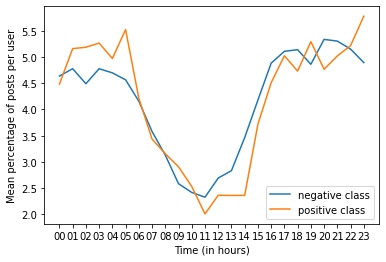

In [ ]:
from matplotlib import pyplot as plt
time = ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11',
        '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23']

plt.xlabel("Time (in hours)")

plt.ylabel("Mean percentage of posts per user")

plt.plot(time, avg_neg_time_series)
plt.plot(time, avg_pos_time_series)

plt.legend(["negative class", "positive class"], loc ="lower right") 

In [ ]:
from scipy import stats

stat, p = stats.ks_2samp(pos_avg_post_dist, neg_avg_post_dist)
print('stat=%f, p=%f' % (stat, p))
if p > 0.05:
	print('Probably the same distribution')
else:
	print('Probably different distributions')

stat=0.228907, p=0.000008
Probably different distributions


In [ ]:
from scipy import stats

stat, p = stats.kruskal(pos_avg_post_dist, neg_avg_post_dist)
print('stat=%f, p=%f' % (stat, p))
if p > 0.05:
	print('Probably the same distribution')
else:
	print('Probably different distributions')

stat=22.481007, p=0.000002
Probably different distributions


In [ ]:
from scipy.stats import shapiro
stat, p = shapiro(avg_pos_time_series)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('Probably Gaussian')
else:
	print('Probably not Gaussian')

stat=0.882, p=0.009
Probably not Gaussian


In [ ]:
from scipy.stats import shapiro
stat, p = shapiro(avg_neg_time_series)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('Probably Gaussian')
else:
	print('Probably not Gaussian')

stat=0.868, p=0.005
Probably not Gaussian


In [ ]:
from scipy import stats

stat, p = stats.ks_2samp(avg_pos_time_series, avg_neg_time_series)
print('stat=%f, p=%f' % (stat, p))
if p > 0.05:
	print('Probably the same distribution')
else:
	print('Probably different distributions')

stat=0.208333, p=0.686017
Probably the same distribution


In [ ]:
final_data = final_negative_data + final_positive_data
len(final_data)

892

In [ ]:
final_data_df = pd.DataFrame(final_data)
final_data_df.head()

,text,00-05,06-11,12-17,18-23,class
0,"I already try to talk to her, in my experienc...",58,29,172,201,0
1,"wow, what a dive. I never seen before :P Lu...",2,33,11,0,0
2,It's a sad day in America when anyone is stil...,479,235,228,496,0
3,[Album] (http://imgur.com/gallery/Zc4dQ) ...,837,108,303,571,0
4,His approval rating dipped below 30% wh...,326,411,232,641,0


In [ ]:
final_data_df.shape

(892, 6)

In [ ]:
#Saving to excel format
final_data_df.to_excel('/content/reddit_data.xlsx', sheet_name = 'Sheet 1', encoding = 'utf-8')